In [1]:
import pandas as pd
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objs as go
import numpy as np

%matplotlib inline
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
data = pd.read_csv('assist09_processed.csv', encoding="ISO-8859-1", low_memory=False)
data.shape, data.columns

((274590, 31),
 Index(['Unnamed: 0', 'order_id', 'assignment_id', 'user_id', 'assistment_id',
        'problem_id', 'original', 'correct', 'attempt_count',
        'ms_first_response', 'tutor_mode', 'answer_type', 'sequence_id',
        'student_class_id', 'position', 'type', 'base_sequence_id', 'skill_id',
        'skill_name', 'teacher_id', 'school_id', 'hint_count', 'hint_total',
        'overlap_time', 'template_id', 'answer_id', 'answer_text',
        'first_action', 'bottom_hint', 'opportunity', 'opportunity_original'],
       dtype='object'))

In [3]:
key = 'problem_id'
diff = data[[key, 'correct']].groupby([key]).apply(lambda r:r['correct'].sum() / len(r['correct']))
diff

problem_id
83        0.5
84        0.0
85        0.2
86        0.5
249       0.0
         ... 
189408    1.0
189554    1.0
189565    0.0
189566    1.0
196456    0.0
Length: 16891, dtype: float64

In [4]:
key_qd = 'difficulty'
data[key_qd] = data['problem_id'].map(diff)
data.head(), data.shape, data.columns

(   Unnamed: 0  order_id  assignment_id  user_id  assistment_id  problem_id  \
 0           1  33022537         277618    64525          33139       51424   
 1           2  33022709         277618    64525          33150       51435   
 2           3  35450204         220674    70363          33159       51444   
 3           4  35450295         220674    70363          33110       51395   
 4           5  35450311         220674    70363          33196       51481   
 
    original  correct  attempt_count  ms_first_response  ... hint_total  \
 0         1        1              1              32454  ...          3   
 1         1        1              1               4922  ...          3   
 2         1        0              2              25390  ...          3   
 3         1        1              1               4859  ...          3   
 4         1        0             14              19813  ...          4   
 
   overlap_time  template_id  answer_id  answer_text first_action  botto

In [5]:
key_s = 'skill_id'
skill_id_dict = dict(zip(data['skill_name'].unique(), range(len(data['skill_name'].unique()))))
data[key_s] = data['skill_name'].map(skill_id_dict)
data.head(), data.shape, data.columns

(   Unnamed: 0  order_id  assignment_id  user_id  assistment_id  problem_id  \
 0           1  33022537         277618    64525          33139       51424   
 1           2  33022709         277618    64525          33150       51435   
 2           3  35450204         220674    70363          33159       51444   
 3           4  35450295         220674    70363          33110       51395   
 4           5  35450311         220674    70363          33196       51481   
 
    original  correct  attempt_count  ms_first_response  ... hint_total  \
 0         1        1              1              32454  ...          3   
 1         1        1              1               4922  ...          3   
 2         1        0              2              25390  ...          3   
 3         1        1              1               4859  ...          3   
 4         1        0             14              19813  ...          4   
 
   overlap_time  template_id  answer_id  answer_text first_action  botto

In [6]:
df = data[data.skill_id < 10]
df.head(), df.shape, df.columns

(   Unnamed: 0  order_id  assignment_id  user_id  assistment_id  problem_id  \
 0           1  33022537         277618    64525          33139       51424   
 1           2  33022709         277618    64525          33150       51435   
 2           3  35450204         220674    70363          33159       51444   
 3           4  35450295         220674    70363          33110       51395   
 4           5  35450311         220674    70363          33196       51481   
 
    original  correct  attempt_count  ms_first_response  ... hint_total  \
 0         1        1              1              32454  ...          3   
 1         1        1              1               4922  ...          3   
 2         1        0              2              25390  ...          3   
 3         1        1              1               4859  ...          3   
 4         1        0             14              19813  ...          4   
 
   overlap_time  template_id  answer_id  answer_text first_action  botto

In [7]:
import os
import random
import numpy as np
seed = 1024
random.seed(seed)     # python的随机性
np.random.seed(seed)

In [8]:
df1 = df.sample(n=200, axis=0)
df1.head(), df1.shape, df1.columns

(       Unnamed: 0  order_id  assignment_id  user_id  assistment_id  \
 10364       10365  35231959         281005    78911          33068   
 21197       21198  31510607         271210    78903          36494   
 10641       10642  28614900         270282    78984          53111   
 22953       22954  23231430         265827    79582          59497   
 14644       14645  30943124         271978    79075          36434   
 
        problem_id  original  correct  attempt_count  ms_first_response  ...  \
 10364       51353         1        1              1              25851  ...   
 21197       56832         1        1              1             491842  ...   
 10641       93071         1        1              1              26859  ...   
 22953      112910         1        0              1             102672  ...   
 14644       56690         1        1              1               4374  ...   
 
       hint_total overlap_time  template_id  answer_id  answer_text  \
 10364          4  

In [9]:
import os
os.getcwd()

'/home/czy/KT/1/dataset/assist09'

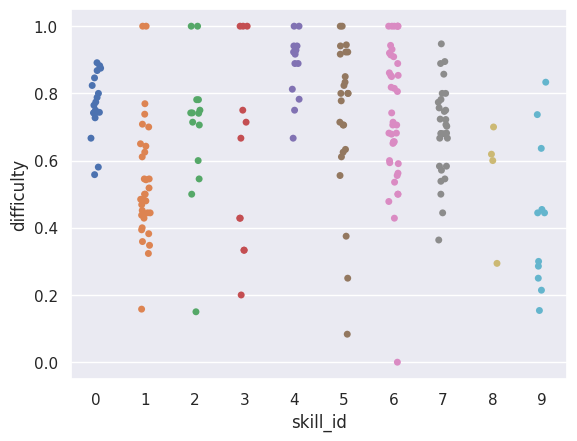

In [10]:
sns.stripplot(x='skill_id', y='difficulty', data=df1)
plt.savefig('/home/czy/KT/1/pictures/fig6_assist09_difficulty.eps', dpi=300)  # eps文件，用于LaTeX
plt.show()